In [1]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.circuit.library import RYGate
from qiskit_aer import AerSimulator
from shift_operators import ShiftDown, ShiftUp

In [ ]:
def equal_superposition(k, nq=None):
    """Creates a quantum circuit that creates an equal superposition between |0> and |k-1>.
    
    Args:
        k: Number of states in superposition.
        nq: Number of qubits in the register.
        
    Returns:
        a qiskit.QuantumCircuit object containing a circuit that maps a state 0 to equal superposition state.
    """
    if nq is None:
        nq = int(np.ceil(np.log2(k)))

    qc = QuantumCircuit(nq)

    # If k equals 1, do nothing
    if k == 1:
        return qc
    
    # If k is a power of 2, then an array of hadamard gets the job done
    elif (k & (k - 1)) == 0:
        qc.h(range(int(np.log2(k))))

        return qc
    
    # Otherwize apply ry on last qubit to obtain state sqrt(n_xtra / k) |100...0> + sqrt(1 - n_xtra / k) |000...0>.
    # The |000...0> state gets mapped to |0++...+> with controlled hadamard gates.
    # The |100...0> state gets mapped to |1> tensored with a quantum state of nq-1 qubits in an equal superposition
    # state of states |0> through |n_extra_states>.
    # This is achieved via recursive application of a controlled version of this circuit.
    # The result is a state with nq qubits in equal superposition state from |0> to |k>.
    # Total recursion depth is linear in number of qubits.
    n_extra_states = k - 2 ** (nq-1)
    theta = 2 * np.arcsin(np.sqrt(n_extra_states / k))

    qc.ry(theta, nq-1)

    # Apply controlled hadamards.
    qc.x(nq-1)
    qc.ch(nq-1, range(nq-1))
    qc.x(nq-1)

    # Apply recursive application of the circuit.
    circuit = equal_superposition(n_extra_states, nq-1)
    gate = circuit.to_gate().control(1)
    qc.append(gate, [nq-1] + list(range(nq-1)))

    return qc

In [ ]:
def generate_laplacian_block_encoding(nq, bcs, normalize=1):
    r"""Build the quantum circuit for the block encoding of an N-dimensional Laplacian operator
    
    Args:
        nq (int): Number of qubits per dimensions. Corresponds to 2**nq grid points per dimension.
        bcs (list[str]): Boundary conditions of the laplacian. Each item in the list is either "periodic"
            or "dirichlet". The length of the list determines the number of dimensions.
            
    Returns:
        a numpy.ndarray representing the unitary operation equivalent to the quantum circuit to block encode
        the Laplacian operator.
    """
    if len(list(filter(lambda x: x != "dirichlet" and x != "periodic", bcs))) != 0:
        raise ValueError("Invalid boundary conditions")
    
    d = len(bcs)
    k = int(np.ceil(np.log2(d)))

    # Y rotation angles used for block encoding of Laplacian
    theta_diag = 2 * np.arccos(1/2 - 1)
    theta_off = 2 * np.arccos(-1/4)
    
    # Defining registers
    l_reg = QuantumRegister(2, "l")
    data_reg = QuantumRegister(1, "data")
    j_regs = [QuantumRegister(nq, f"^{{({i})}}") for i in range(d)]
    k_reg = QuantumRegister(k, "k")

    simulator = AerSimulator(method="unitary")

    ry_diag = RYGate(theta_diag)
    ry_off = RYGate(theta_off)
    shift_up = ShiftUp(nq)
    shift_down = ShiftDown(nq)

    if k == 0:
        qc = QuantumCircuit(*j_regs, data_reg, l_reg)

        # Defining multi controlled RY gates
        ry_diag_mc0 = ry_diag.control(2, ctrl_state="00")
        ry_off_mc1 = ry_off.control(2, ctrl_state="01")
        ry_off_mc2 = ry_off.control(2, ctrl_state="10")
        su_mc1 = shift_up.control(2, ctrl_state="01")
        sd_mc2 = shift_down.control(2, ctrl_state="10")

        # Building circuit
        qc.h(l_reg)
        qc.barrier()

        # Apply mcRY gates for main and off diagonal entries of laplacian
        qc.append(ry_diag_mc0, l_reg[:] + data_reg[:])
        qc.append(ry_off_mc1, l_reg[:] + data_reg[:])
        qc.append(ry_off_mc2, l_reg[:] + data_reg[:])

        # Apply dirichlet extra gates if BC is Dirichlet
        if bcs[0] == "dirichlet":
            ry_dirichlet = RYGate(np.pi - theta_off)
            
            ryd_mc1 = ry_dirichlet.control(nq + 2, ctrl_state="1" * nq + "01")
            ryd_mc2 = ry_dirichlet.control(nq + 2, ctrl_state="0" * nq + "10")

            qc.append(ryd_mc1, l_reg[:] + j_regs[0][:] + data_reg[:])
            qc.append(ryd_mc2, l_reg[:] + j_regs[0][:] + data_reg[:])

        # Apply shift operators
        qc.append(sd_mc2, l_reg[:] + j_regs[0][:])
        qc.append(su_mc1, l_reg[:] + j_regs[0][:])
        qc.barrier()

        qc.h(l_reg)
        qc.save_unitary()

    else:
        qc = QuantumCircuit(*j_regs, data_reg, l_reg, k_reg)
        equal_superposition_circuit = equal_superposition(d)
        inv_equal_superposition_circuit = equal_superposition_circuit.inverse()

        qc.h(l_reg)
        qc.append(equal_superposition_circuit.to_instruction(), k_reg)
        qc.barrier()
        
        for i in range(len(bcs)):
            # Control bitstring for k register
            k_ctrl = bin(i)[2:].zfill(k)

            # Defining multi controlled RY gates
            ry_diag_mc0 = ry_diag.control(k + 2, ctrl_state="00" + k_ctrl)
            ry_off_mc1 = ry_off.control(k + 2, ctrl_state="01" + k_ctrl)
            ry_off_mc2 = ry_off.control(k + 2, ctrl_state="10" + k_ctrl)
            su_mc1 = shift_up.control(k + 2, ctrl_state="01" + k_ctrl)
            sd_mc2 = shift_down.control(k + 2, ctrl_state="10" + k_ctrl)

            # Apply mcRY gates for main and off diagonal entries of laplacian
            qc.append(ry_diag_mc0, k_reg[:] + l_reg[:] + data_reg[:])
            qc.append(ry_off_mc1, k_reg[:] + l_reg[:] + data_reg[:])
            qc.append(ry_off_mc2, k_reg[:] + l_reg[:] + data_reg[:])

            # Apply dirichlet extra gates if current BC is Dirichlet
            if bcs[i] == "dirichlet":
                ry_dirichlet = RYGate(np.pi - theta_off)
                ryd_mc1 = ry_dirichlet.control(k + nq + 2, ctrl_state="1" * nq + "01" + k_ctrl)
                ryd_mc2 = ry_dirichlet.control(k + nq + 2, ctrl_state="0" * nq + "10" + k_ctrl)

                qc.append(ryd_mc1, k_reg[:] + l_reg[:] + j_regs[i][:] + data_reg[:])
                qc.append(ryd_mc2, k_reg[:] + l_reg[:] + j_regs[i][:] + data_reg[:])

            # Apply shift operators
            qc.append(sd_mc2, k_reg[:] + l_reg[:] + j_regs[i][:])
            qc.append(su_mc1, k_reg[:] + l_reg[:] + j_regs[i][:])
            qc.barrier()

        qc.h(l_reg)
        qc.append(inv_equal_superposition_circuit.to_instruction(), k_reg)
        qc.save_unitary()

    qc = transpile(qc, simulator)

    result = simulator.run(qc).result()
    unitary = result.get_unitary(qc).data.real
    unitary_subspace = unitary[:2 ** (nq * d), :2 ** (nq * d)]

    unitary_subspace = (unitary_subspace / unitary_subspace[0, 0]) * normalize

    return unitary_subspace

In [4]:
def plot_heatmap(nq, bcs, normalize, ncs=50, vmax=1.0):
    """Creates a heatmap plot of the block encoded Laplacian in the circuit unitary.
    
    Args:
        nq (int): Number of qubits per dimensions. Corresponds to 2**nq grid points per dimension.
        bcs (list[str]): Boundary conditions of the laplacian. Each item in the list is either "periodic"
            or "dirichlet". The length of the list determines the number of dimensions.
        normalize (float): Value of the [0, 0] entry in the output matrix. Scaling is applied to entire matrix.
        ncs (int): Number of colors in the colorbar.
        vmax (float): Maximum value used in the colorbar.
    """
    unitary = generate_laplacian_block_encoding(nq, bcs, normalize)
    cmap = plt.get_cmap("seismic", ncs)

    plt.imshow(unitary, cmap=cmap, vmin=-vmax, vmax=vmax)
    plt.colorbar()
    plt.show()

Sturm et al. Figure 3b


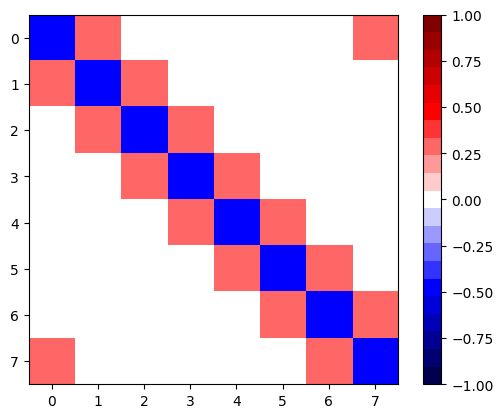

Sturm et al. Figure 6b


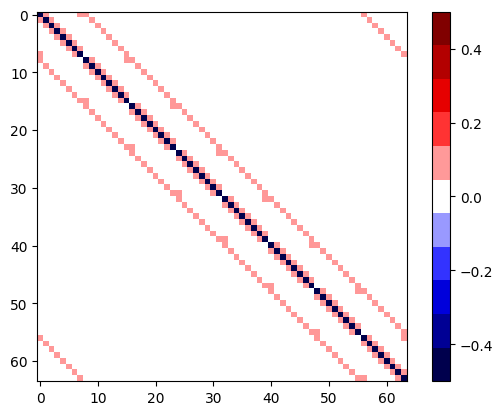

Sturm et al. Figure 7b


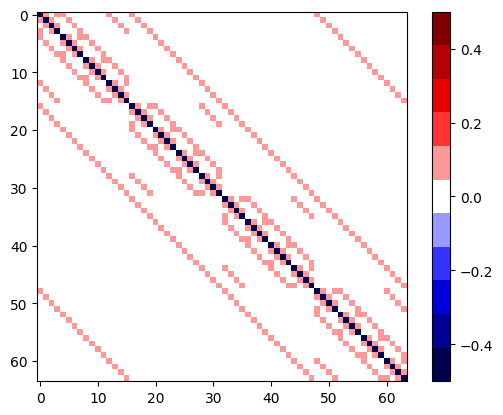

In [5]:
# Here are reproduced plots from papers
print("Sturm et al. Figure 3b")
plot_heatmap(3, ["periodic"], -0.5, 21, 1)

print("Sturm et al. Figure 6b")
plot_heatmap(3, ["periodic", "periodic"], -0.5, 11, 0.5)

print("Sturm et al. Figure 7b")
plot_heatmap(2, ["periodic", "periodic", "periodic"], -0.5, 11, 0.5)

Boundary conditons: ['dirichlet']


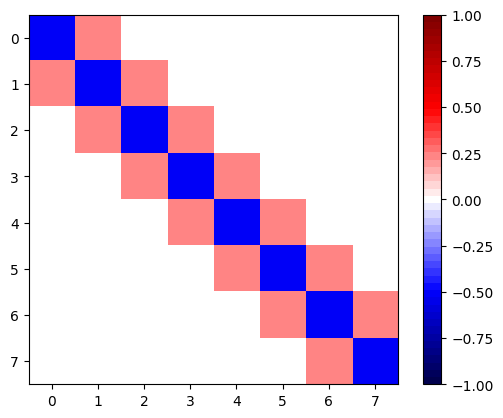

Boundary conditons: ['dirichlet', 'dirichlet']


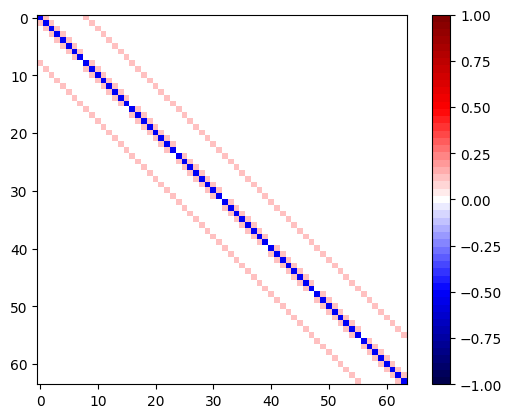

Boundary conditons: ['dirichlet', 'periodic']


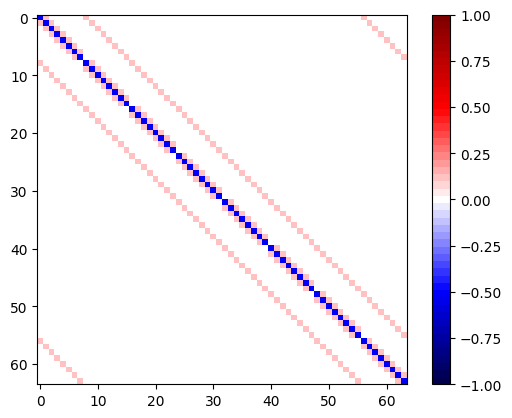

Boundary conditons: ['periodic', 'dirichlet']


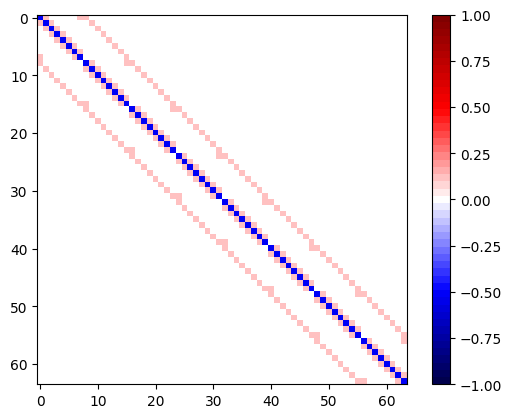

Boundary conditons: ['periodic', 'dirichlet', 'periodic']



thread '<unnamed>' panicked at crates/transpiler/src/passes/basis_translator/compose_transforms.rs:186:9:
internal error: entered unreachable code: Having a unitary result from an `EquivalenceLibrary is not possible
note: run with `RUST_BACKTRACE=1` environment variable to display a backtrace


PanicException: internal error: entered unreachable code: Having a unitary result from an `EquivalenceLibrary is not possible

In [7]:
# Some heatmaps with Dirichlet boundary conditions
bcs = ["dirichlet"]
print("Boundary conditons:", bcs)
plot_heatmap(3, bcs, -0.5, 51, 1)

bcs = ["dirichlet", "dirichlet"]
print("Boundary conditons:", bcs)
plot_heatmap(3, bcs, -0.5, 51, 1)

bcs = ["dirichlet", "periodic"]
print("Boundary conditons:", bcs)
plot_heatmap(3, bcs, -0.5, 51, 1)

bcs = ["periodic", "dirichlet"]
print("Boundary conditons:", bcs)
plot_heatmap(3, bcs, -0.5, 51, 1)

bcs = ["periodic", "dirichlet", "periodic"]
print("Boundary conditons:", bcs)
plot_heatmap(2, bcs, -0.5, 51, 1)